# 1) Activation Functions

(A) Non-linear activation functions allow the neural network to describe non-linear relations between input and the output. If a linear activation function was used at each hidden unit, the mapping from input to output would be restricted to be linear.

(B) Two example activation functions  

1. ReLU  
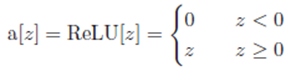  

2. Logistic Sigmoid  
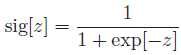

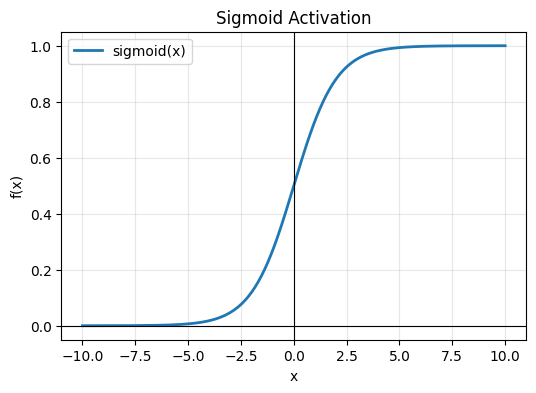

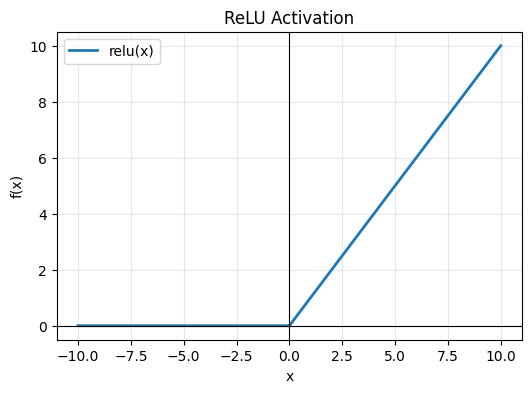

In [5]:
import os
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

os.makedirs('images', exist_ok=True)

x = np.linspace(-10, 10, 400)
y_sigmoid = sigmoid(x)
y_relu = relu(x)

# Sigmoid
plt.figure(figsize=(6, 4))
plt.plot(x, y_sigmoid, label='sigmoid(x)', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Sigmoid Activation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('images/sigmoid_activation.png', dpi=150, bbox_inches='tight')
plt.show()

# ReLU
plt.figure(figsize=(6, 4))
plt.plot(x, y_relu, label='relu(x)', linewidth=2)
plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('ReLU Activation')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig('images/relu_activation.png', dpi=150, bbox_inches='tight')
plt.show()

(C) A regression problem returns a continuous number for a variable you are trying to predict as its ouput, while a classification problem returns a category assignment via a probability for each potential class in the form of a vector. For regression I would use a linear activation function that essentially passes the value through to the output. Since the continuous number could be positive or negative, I would not use a ReLU activation function. For a classification problem, I would use the sigmoid activation function because it outputs a value between 0-1 which would represent a probability.

(D)  
(i)  

<img src="images/pd1.jpg" width="600">  

(ii)  

<img src="images/pd2.png" width="350">

# 2) Loss Functions

(a)

In [9]:
# Load dataset from Hugging Face
from datasets import load_dataset

dataset_name = "lamm-mit/data_sample"   # change this
ds = load_dataset(dataset_name, download_mode="force_redownload")

print(ds)
print(ds["train"][0])

Generating train split: 100%|██████████| 400/400 [00:00<00:00, 69124.54 examples/s]

DatasetDict({
    train: Dataset({
        features: ['Unnamed: 0', 'ground truth', 'prediction'],
        num_rows: 400
    })
})
{'Unnamed: 0': 0, 'ground truth': 0.2186085658412798, 'prediction': 0.2301788661709234}


In [27]:
import numpy as np


# Calculate MAE
df = ds["train"].to_pandas()
selected = df[["ground truth", "prediction"]].copy()

y_true = selected["ground truth"].astype(float).to_numpy()
y_pred = selected["prediction"].astype(float).to_numpy()

mae = np.mean(np.abs(y_true - y_pred))
print("MAE: " + str(mae))

# Calculate MSE
mse = np.mean((y_true - y_pred) ** 2)
print("MSE: " + str(mse))

# Coefficient of determination for predictions
y_true_series = selected["ground truth"].astype(float)
y_pred_series = selected["prediction"].astype(float)
ss_res = ((y_true_series - y_pred_series) ** 2).sum()
ss_tot = ((y_true_series - y_true_series.mean()) ** 2).sum()
r2_pred = 1 - (ss_res / ss_tot)
print("R^2 : " + str(r2_pred))

MAE: 0.01832773426808224
MSE: 0.000458758238585838
R^2 : 0.898312268689691


(b) MAE looks at the average absolute error of the predictions. If outliers exist within the dataset, MAE will prevent them from dominating the training error. It is better for when the engineer wants the typical absolute error and potentially for explainability since the units are the same as the gorund truth data. MSE looks at the average of squared mistakes. If there are outliers, they will be penalized heavier due to the squared term. This makes MSE ideal for use cases where large errors are much worse than small ones. 

# 3) Beam Mechanics